# Lab 7 — Decision Trees on the Iris Dataset

## Task 1: Dataset Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Feature names:", feature_names)
print("Target classes:", list(target_names))

Samples: 150
Features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [2]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map(dict(enumerate(target_names)))
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Class distribution:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


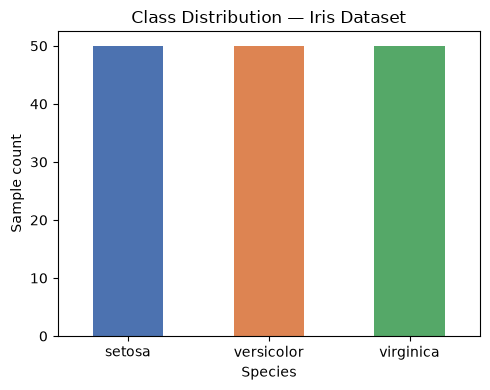

In [3]:
class_counts = df['species'].value_counts()
print("Class distribution:\n", class_counts)

plt.figure(figsize=(5, 4))
class_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Class Distribution — Iris Dataset")
plt.xlabel("Species")
plt.ylabel("Sample count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Reasoning: the dataset has 150 samples across 4 numeric features and 3 perfectly balanced classes of 50 samples each, so accuracy is a fair metric without needing class-imbalance correction.

## Task 2: Data Preparation

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 120
Test size: 30


Reasoning: splitting into train and test sets lets us measure performance on unseen data rather than on data the tree has memorized, and random_state=42 with stratify=y keeps the split reproducible and class-balanced.

## Task 3: Building a Decision Tree Classifier

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dt = DecisionTreeClassifier(random_state=42)  # default params (criterion='gini')
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc:.4f}")

Accuracy Score: 0.9333


Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


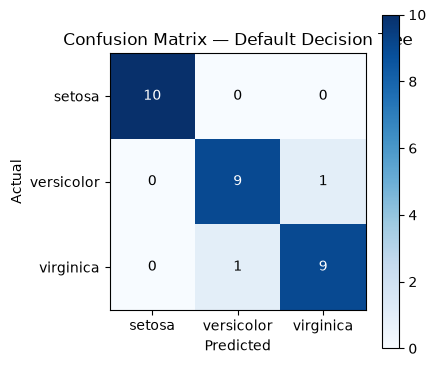

In [6]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(target_names); ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Default Decision Tree")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [7]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Reasoning: the confusion matrix and classification report are computed only on the held-out test set, so the reported accuracy reflects true generalization rather than memorization of the training data.

## Task 4: Visualizing the Decision Tree

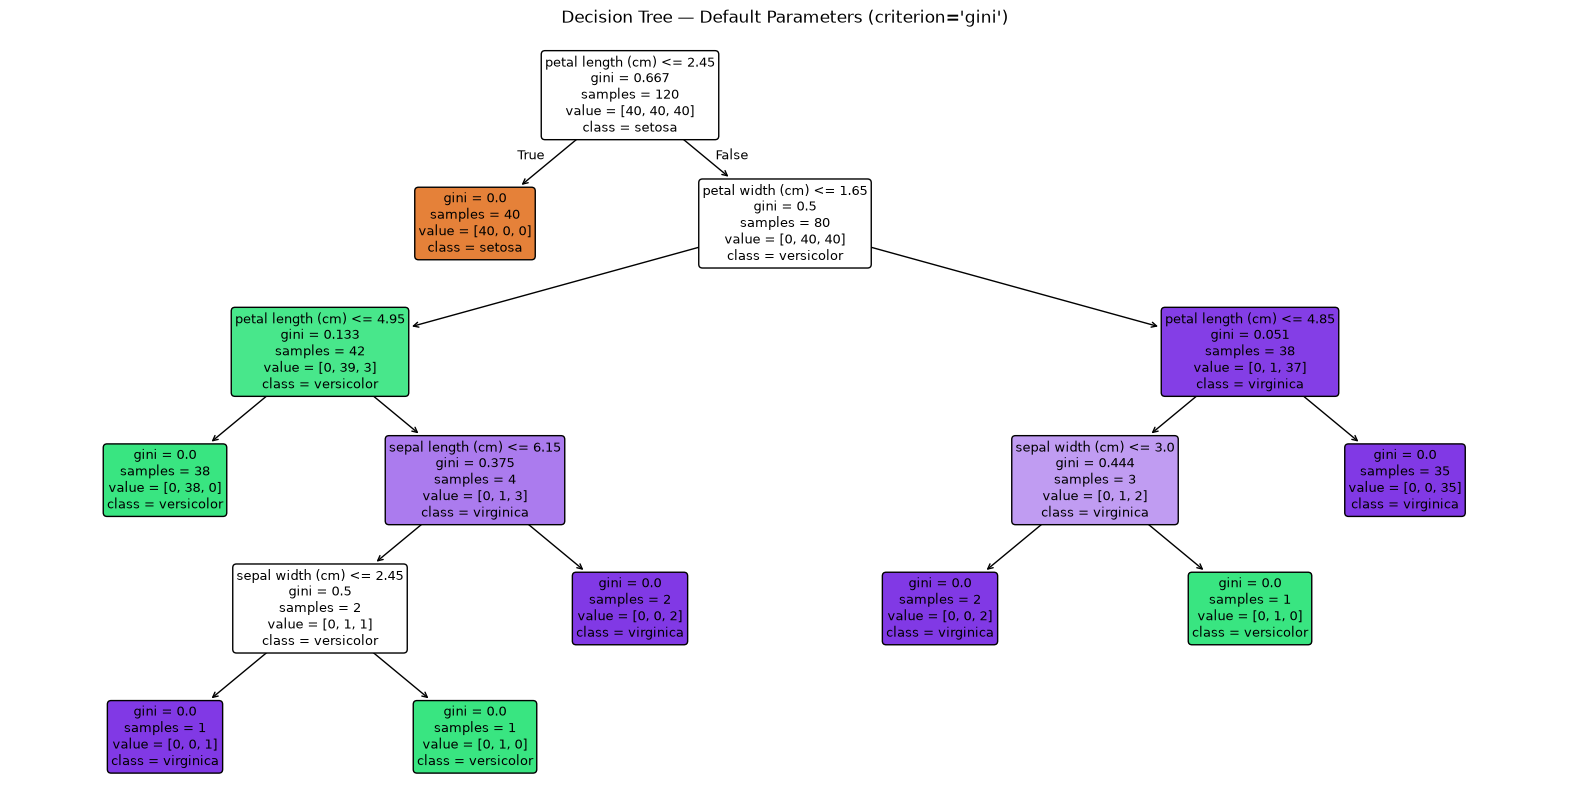

Tree depth: 5
Number of leaf nodes: 8
Root split feature: petal length (cm)
Root split threshold: 2.45


In [8]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=feature_names, class_names=target_names,
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree — Default Parameters (criterion='gini')")
plt.show()

print("Tree depth:", dt.get_depth())
print("Number of leaf nodes:", dt.get_n_leaves())
print("Root split feature:", feature_names[dt.tree_.feature[0]])
print("Root split threshold:", round(dt.tree_.threshold[0], 2))

Node identification:
- Root node: the top box, splitting on petal length (cm).
- Internal nodes: every box beneath the root that still carries a further split condition.
- Leaf nodes: the terminal boxes with no further condition, each reporting one predicted class.
- Maximum depth: read directly from the printed dt.get_depth() output above.

In [9]:
def gini_impurity(labels):
    counts = np.bincount(labels, minlength=3)
    probs = counts / counts.sum()
    return 1 - np.sum(probs ** 2)

def entropy_impurity(labels):
    counts = np.bincount(labels, minlength=3)
    probs = counts[counts > 0] / counts.sum()
    return -np.sum(probs * np.log2(probs))

root_feature_idx = dt.tree_.feature[0]
root_threshold = dt.tree_.threshold[0]
left_mask = X_train[:, root_feature_idx] <= root_threshold
right_mask = ~left_mask
y_left, y_right = y_train[left_mask], y_train[right_mask]

parent_gini, parent_entropy = gini_impurity(y_train), entropy_impurity(y_train)
left_gini, right_gini = gini_impurity(y_left), gini_impurity(y_right)
left_entropy, right_entropy = entropy_impurity(y_left), entropy_impurity(y_right)

n = len(y_train)
w_left, w_right = len(y_left) / n, len(y_right) / n
weighted_gini = w_left * left_gini + w_right * right_gini
weighted_entropy = w_left * left_entropy + w_right * right_entropy
gini_gain = parent_gini - weighted_gini
info_gain = parent_entropy - weighted_entropy

print(f"Root split: {feature_names[root_feature_idx]} <= {root_threshold:.2f}")
print(f"Parent Gini = {parent_gini:.4f}, Parent Entropy = {parent_entropy:.4f} bits")
print(f"Left child (n={len(y_left)}): Gini = {left_gini:.4f}, Entropy = {left_entropy:.4f}")
print(f"Right child (n={len(y_right)}): Gini = {right_gini:.4f}, Entropy = {right_entropy:.4f}")
print(f"Weighted child Gini = {weighted_gini:.4f}  ->  Gini gain = {gini_gain:.4f}")
print(f"Weighted child Entropy = {weighted_entropy:.4f}  ->  Information gain = {info_gain:.4f} bits")

Root split: petal length (cm) <= 2.45
Parent Gini = 0.6667, Parent Entropy = 1.5850 bits
Left child (n=40): Gini = 0.0000, Entropy = -0.0000
Right child (n=80): Gini = 0.5000, Entropy = 1.0000
Weighted child Gini = 0.3333  ->  Gini gain = 0.3333
Weighted child Entropy = 0.6667  ->  Information gain = 0.9183 bits


Reasoning: the root split cuts training Gini impurity from 0.6667 to a weighted 0.3333 for a Gini gain of 0.3333, and cuts entropy from 1.585 bits to a weighted 0.6667 bits for an information gain of 0.9183 bits, and the left child is perfectly pure (Gini 0, entropy 0 bits) because it isolates all 40 setosa samples.

In [10]:
def best_gini_gain(x, labels):
    parent = gini_impurity(labels)
    n = len(labels)
    xs = np.unique(x)
    thresholds = (xs[:-1] + xs[1:]) / 2
    best_gain, best_t = -1, None
    for t in thresholds:
        left, right = labels[x <= t], labels[x > t]
        if len(left) == 0 or len(right) == 0:
            continue
        w_l, w_r = len(left) / n, len(right) / n
        g = parent - (w_l * gini_impurity(left) + w_r * gini_impurity(right))
        if g > best_gain:
            best_gain, best_t = g, t
    return best_gain, best_t

def best_info_gain(x, labels):
    parent = entropy_impurity(labels)
    n = len(labels)
    xs = np.unique(x)
    thresholds = (xs[:-1] + xs[1:]) / 2
    best_gain, best_t = -1, None
    for t in thresholds:
        left, right = labels[x <= t], labels[x > t]
        if len(left) == 0 or len(right) == 0:
            continue
        w_l, w_r = len(left) / n, len(right) / n
        g = parent - (w_l * entropy_impurity(left) + w_r * entropy_impurity(right))
        if g > best_gain:
            best_gain, best_t = g, t
    return best_gain, best_t

rows_split = []
for i, name in enumerate(feature_names):
    gg, gt = best_gini_gain(X_train[:, i], y_train)
    ig, it = best_info_gain(X_train[:, i], y_train)
    rows_split.append({
        'feature': name,
        'best_gini_gain': round(gg, 4),
        'gini_threshold': round(gt, 2),
        'best_info_gain_bits': round(ig, 4),
        'entropy_threshold': round(it, 2),
    })

df_splits = pd.DataFrame(rows_split).sort_values('best_gini_gain', ascending=False)
df_splits

,feature,best_gini_gain,gini_threshold,best_info_gain_bits,entropy_threshold
2,petal length (cm),0.3333,2.45,0.9183,2.45
3,petal width (cm),0.3333,0.80,0.9183,0.80
0,sepal length (cm),0.2528,5.45,0.6179,5.55
1,sepal width (cm),0.1119,3.35,0.2664,2.95


Reasoning: petal length and petal width tie for the highest possible Gini gain (0.3333) and information gain (0.9183 bits) among all four features because both perfectly separate the 40 setosa samples from the rest, and the tree picks petal length as the root only because it is evaluated first when the gain is tied.

## Task 5: Comparing Gini Index and Entropy

In [11]:
results_5 = []
for crit in ['gini', 'entropy']:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    results_5.append({
        'criterion': crit,
        'accuracy': accuracy_score(y_test, pred),
        'tree_depth': clf.get_depth(),
        'n_leaves': clf.get_n_leaves(),
        'root_feature': feature_names[clf.tree_.feature[0]],
    })

df5 = pd.DataFrame(results_5)
df5

,criterion,accuracy,tree_depth,n_leaves,root_feature
0,gini,0.933333,5,8,petal length (cm)
1,entropy,0.933333,5,8,petal length (cm)


Observations table (from the run above):

| Criterion | Accuracy | Tree Depth | Leaf Nodes | Root Feature |
|---|---|---|---|---|
| Gini | 0.933 | 5 | 8 | petal length (cm) |
| Entropy | 0.933 | 5 | 8 | petal length (cm) |

Reasoning: the entropy-criterion tree lands on the exact same root split as the Gini-criterion tree because petal length maximizes both impurity measures simultaneously (Gini gain 0.3333, information gain 0.9183 bits), so the two criteria produce identical trees on Iris and neither is simpler than the other here.

## Task 6: Effect of Maximum Tree Depth

In [12]:
rows = []
for d in [1, 2, 3, 4, None]:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    rows.append({
        'max_depth': d if d is not None else 'None',
        'train_accuracy': round(train_acc, 4),
        'test_accuracy': round(test_acc, 4),
        'tree_depth': clf.get_depth(),
    })

df6 = pd.DataFrame(rows)
df6

,max_depth,train_accuracy,test_accuracy,tree_depth
0,1,0.6667,0.6667,1
1,2,0.9667,0.9333,2
2,3,0.9833,0.9667,3
3,4,0.9917,0.9333,4
4,None,1.0000,0.9333,5


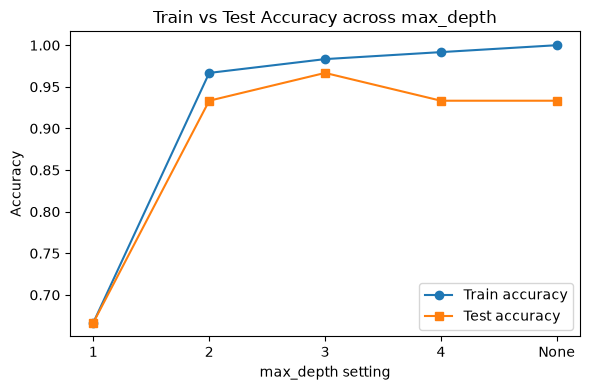

In [13]:
plt.figure(figsize=(6, 4))
labels = [str(r['max_depth']) for r in rows]
plt.plot(labels, [r['train_accuracy'] for r in rows], marker='o', label='Train accuracy')
plt.plot(labels, [r['test_accuracy'] for r in rows], marker='s', label='Test accuracy')
plt.xlabel('max_depth setting')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across max_depth')
plt.legend()
plt.tight_layout()
plt.show()

Completed table (actual results):

| Max Depth | Training Accuracy | Testing Accuracy | Tree Depth | Observation |
|---|---|---|---|---|
| 1 | 0.667 | 0.667 | 1 | The single Gini-optimal split only isolates setosa, so versicolor and virginica stay mixed. |
| 2 | 0.967 | 0.933 | 2 | A second split on petal width resolves most of the remaining impurity. |
| 3 | 0.983 | 0.967 | 3 | Test accuracy peaks here with only 3 levels of splits. |
| 4 | 0.992 | 0.933 | 4 | Training impurity keeps shrinking but the extra split does not generalize. |
| None | 1.000 | 0.933 | 5 | The tree grows until every leaf is Gini-pure, matching the training set exactly. |

Which model is underfitting: max_depth=1, since it scores only 0.667 on both train and test because one split cannot resolve the impurity between versicolor and virginica.

Which model gives the best generalization: max_depth=3, since it reaches the highest test accuracy (0.967) of any setting tested.

Which model is likely to overfit: max_depth=None, since training accuracy reaches a Gini-pure 1.000 at depth 5 while test accuracy actually falls to 0.933, showing the extra splits reduce impurity on training noise rather than on the true decision boundary.

## Task 7: Effect of min_samples_split

In [14]:
rows7 = []
for m in [2, 5, 10, 20]:
    clf = DecisionTreeClassifier(min_samples_split=m, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    rows7.append({
        'min_samples_split': m,
        'accuracy': round(acc, 4),
        'tree_depth': clf.get_depth(),
        'n_leaves': clf.get_n_leaves(),
    })

df7 = pd.DataFrame(rows7)
df7

,min_samples_split,accuracy,tree_depth,n_leaves
0,2,0.9333,5,8
1,5,0.9667,3,5
2,10,0.9667,3,5
3,20,0.9667,3,5


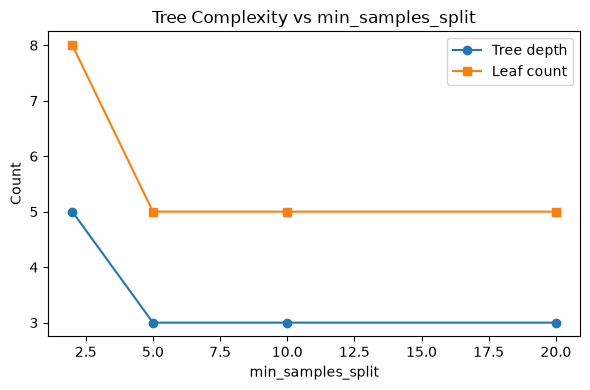

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(df7['min_samples_split'], df7['tree_depth'], marker='o', label='Tree depth')
plt.plot(df7['min_samples_split'], df7['n_leaves'], marker='s', label='Leaf count')
plt.xlabel('min_samples_split')
plt.ylabel('Count')
plt.title('Tree Complexity vs min_samples_split')
plt.legend()
plt.tight_layout()
plt.show()

Completed table (actual results):

| min_samples_split | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| 2 | 0.933 | 5 | 8 | Splits are allowed down to 2 samples, giving the most impurity-driven complexity and the lowest accuracy. |
| 5 | 0.967 | 3 | 5 | Blocking low-support splits removes a low-gain branch and improves test accuracy. |
| 10 | 0.967 | 3 | 5 | Same result as min_samples_split=5, the remaining splits already have enough support. |
| 20 | 0.967 | 3 | 5 | No further pruning occurs because depth has already stabilized at 3. |

Increasing min_samples_split raises the minimum node size required before a Gini-gain split is even considered, so nodes with weak statistical support stop splitting and the tree ends up shallower with fewer leaves.

## Task 8: Effect of min_samples_leaf

In [16]:
rows8 = []
for m in [1, 2, 5, 10]:
    clf = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    rows8.append({
        'min_samples_leaf': m,
        'accuracy': round(acc, 4),
        'tree_depth': clf.get_depth(),
        'n_leaves': clf.get_n_leaves(),
    })

df8 = pd.DataFrame(rows8)
df8

,min_samples_leaf,accuracy,tree_depth,n_leaves
0,1,0.9333,5,8
1,2,0.9333,4,6
2,5,0.9333,3,5
3,10,0.9333,3,5


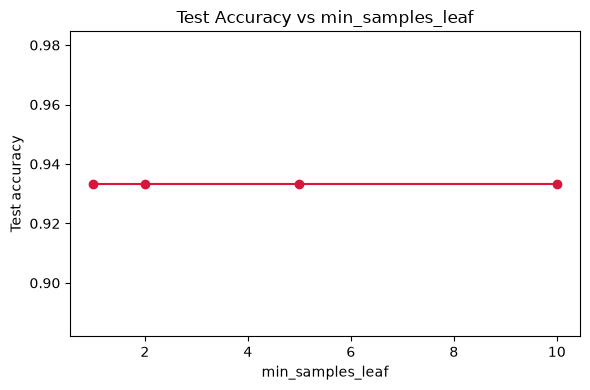

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(df8['min_samples_leaf'], df8['accuracy'], marker='o', color='crimson')
plt.xlabel('min_samples_leaf')
plt.ylabel('Test accuracy')
plt.title('Test Accuracy vs min_samples_leaf')
plt.tight_layout()
plt.show()

Completed table (actual results):

| min_samples_leaf | Accuracy | Tree Depth | Number of Leaf Nodes | Observation |
|---|---|---|---|---|
| 1 | 0.933 | 5 | 8 | Leaves can hold a single sample, letting the tree chase every last bit of Gini gain including noise. |
| 2 | 0.933 | 4 | 6 | One fewer split, accuracy unchanged. |
| 5 | 0.933 | 3 | 5 | Matches the min_samples_split=5 tree in complexity, accuracy still unchanged. |
| 10 | 0.933 | 3 | 5 | Complexity saturates at the same level as min_samples_leaf=5 in this range. |

Forcing a larger min_samples_leaf blocks splits whose child leaves would be too small to trust, which caps how far the tree can chase marginal Gini or entropy gains and therefore reduces its capacity to overfit isolated training points.

## Task 9: Discussion

What is the role of the criterion parameter: it selects the impurity measure, Gini or entropy, used to score every candidate split, and on Iris both measures agreed on the same root split (petal length, Gini gain 0.3333, information gain 0.9183 bits).

How does max_depth influence underfitting and overfitting: a shallow max_depth stops the tree before it can reduce impurity enough to separate all classes, causing underfitting at max_depth=1 (0.667 accuracy), while an unrestricted depth keeps splitting until every leaf is Gini-pure, causing test accuracy to drop from 0.967 at depth 3 to 0.933 at depth 5.

Why do larger min_samples_split and min_samples_leaf produce simpler trees: both parameters block a split from being made or from producing a small child unless enough samples support it, so splits that only reduce impurity on a handful of points are rejected and the tree stays shallower.

Which hyperparameter had the greatest impact: max_depth had the largest effect, moving test accuracy across a 30-point range from 0.667 to 0.967, while min_samples_split and min_samples_leaf only moved accuracy within a 3.4-point band.

Recommended model for the Iris dataset: a tree with max_depth=3 is the best choice because it reaches the highest observed test accuracy of 0.967 with only 3 levels of Gini-driven splits, avoiding the mild overfitting seen once the tree is allowed to grow deeper.